In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

## Load data

In [2]:
df = pd.read_csv('/Users/jamesemcnally/Dropbox/DSBC Student Risk Factors Datasets/combined_presentations_data_w3.csv')

In [3]:
pd.set_option('display.max_columns', 60)

df.head(5)

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,total_vle_pre_w3,content_focus_pre_w3,collaborative_focus_pre_w3,vle_richness_pre_w3,diversity_shannon_pre_w3,active_days_per_week_pre_w3,std_regularity_pre_w3,date,id_assessment,is_banked,score,assessment_type,first_due_date,weight,week,submitted_first_assessment,relative_submission_date,submission_type
0,6516,AAA,2014J,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,269,606.0,0.739274,0.260726,6,2.094273,1.812654,1.358621,17.0,1758.0,0.0,60.0,TMA,19.0,10.0,3.0,1,2.0,Late
1,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN,268,401.0,0.862843,0.137157,6,1.479023,1.414214,2.627691,18.0,1752.0,0.0,78.0,TMA,19.0,10.0,3.0,1,1.0,Late
2,23698,CCC,2014J,F,East Anglian Region,A Level or Equivalent,50-60%,0-35,0,120,N,Pass,-110.0,NaN,269,352.0,0.241477,0.068182,7,1.503976,2.160247,0.770281,21.0,24295.0,0.0,78.0,CMA,18.0,2.0,4.0,1,-3.0,Early
3,23798,BBB,2013J,M,Wales,A Level or Equivalent,50-60%,0-35,0,60,N,Distinction,-27.0,NaN,268,115.0,0.495652,0.504348,7,2.031535,1.414214,3.236694,18.0,14996.0,0.0,90.0,TMA,19.0,5.0,3.0,1,1.0,Late
4,24734,AAA,2014J,F,South Region,Lower Than A Level,60-70%,0-35,0,60,N,Pass,-18.0,NaN,269,87.0,0.781609,0.218391,5,1.777750,0.894427,5.618846,23.0,1758.0,0.0,41.0,TMA,19.0,10.0,4.0,1,-4.0,Early


In [4]:
df.columns

Index(['id_student', 'code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'date_registration',
       'date_unregistration', 'module_presentation_length', 'total_vle_pre_w3',
       'content_focus_pre_w3', 'collaborative_focus_pre_w3',
       'vle_richness_pre_w3', 'diversity_shannon_pre_w3',
       'active_days_per_week_pre_w3', 'std_regularity_pre_w3', 'date',
       'id_assessment', 'is_banked', 'score', 'assessment_type',
       'first_due_date', 'weight', 'week', 'submitted_first_assessment',
       'relative_submission_date', 'submission_type'],
      dtype='object')

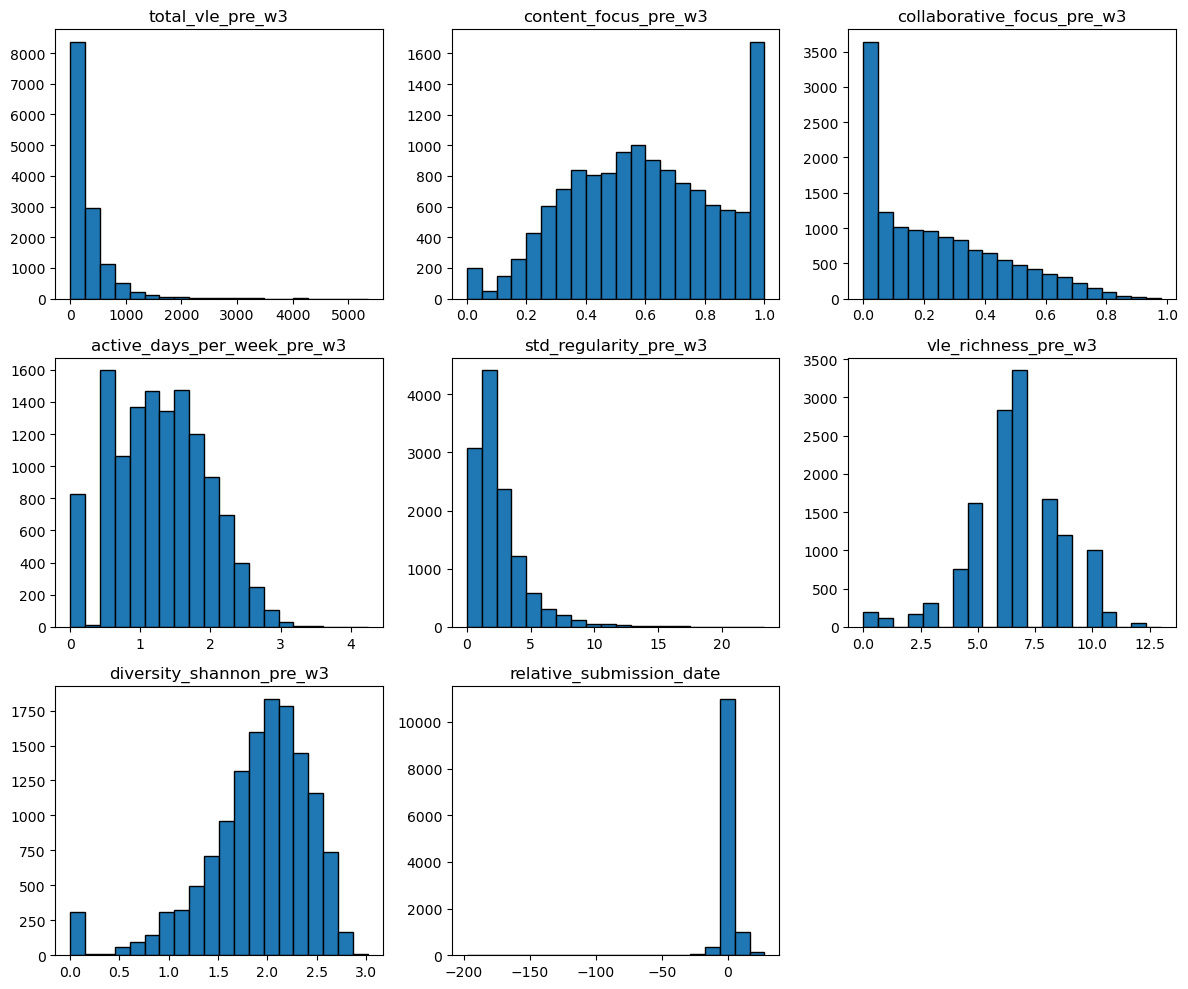

In [5]:
columns_to_display = ['total_vle_pre_w3', 'content_focus_pre_w3',
       'collaborative_focus_pre_w3', 'active_days_per_week_pre_w3',
       'std_regularity_pre_w3', 'vle_richness_pre_w3',
       'diversity_shannon_pre_w3', 'relative_submission_date',
       'submission_type']

# Select only the specified columns and create histograms
df[columns_to_display].hist(bins=20, figsize=(12, 10), edgecolor='black', grid=False)
plt.tight_layout()
plt.show()

In [6]:
# Set random seed for reproducibility
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


Distribution of final_result:

Absolute counts:
final_result
Pass           6240
Fail           3018
Withdrawn      2676
Distinction    1537
Name: count, dtype: int64

Percentage distribution:
final_result
Pass           46.321728
Fail           22.403682
Withdrawn      19.864895
Distinction    11.409695
Name: proportion, dtype: float64


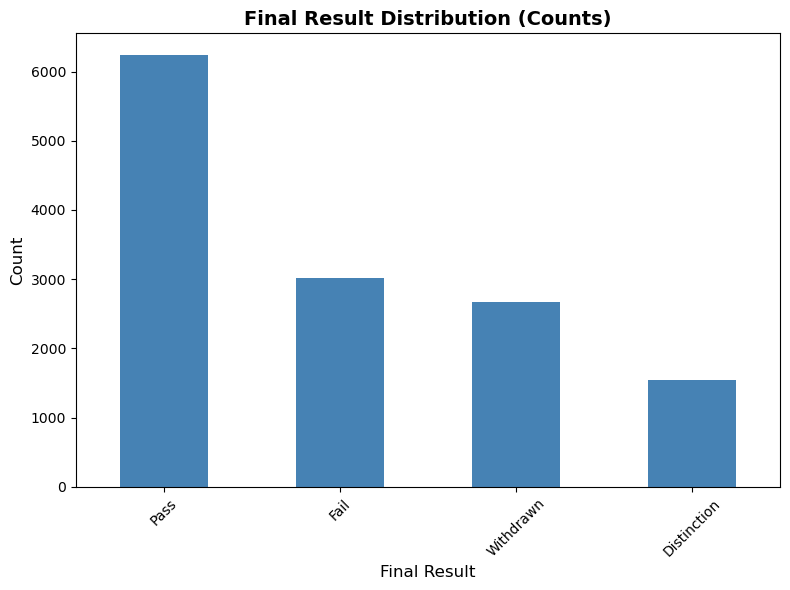


Total students: 13471
Unique categories: 4


In [7]:
# Examine the distribution of final_result

print("Distribution of final_result:")
print("=" * 50)

# Count by category
print("\nAbsolute counts:")
print(df['final_result'].value_counts())

# Percentage distribution
print("\nPercentage distribution:")
print(df['final_result'].value_counts(normalize=True) * 100)

# Visualization - counts only
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

df['final_result'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Final Result Distribution (Counts)', fontsize=14, fontweight='bold')
plt.xlabel('Final Result', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 50)
print(f"Total students: {len(df)}")
print(f"Unique categories: {df['final_result'].nunique()}")

## Data preprocessing

In [8]:
# Check sums of NA in each columns 
print(df.isna().sum())

columns_with_NA = df.columns[df.isna().any()].tolist()

id_student                         0
code_module                        0
code_presentation                  0
gender                             0
region                             0
highest_education                  0
imd_band                         503
age_band                           0
num_of_prev_attempts               0
studied_credits                    0
disability                         0
final_result                       0
date_registration                  0
date_unregistration            10833
module_presentation_length         0
total_vle_pre_w3                   0
content_focus_pre_w3               0
collaborative_focus_pre_w3         0
vle_richness_pre_w3                0
diversity_shannon_pre_w3           0
active_days_per_week_pre_w3      717
std_regularity_pre_w3            981
date                             917
id_assessment                      0
is_banked                        917
score                            933
assessment_type                    0
f

In [9]:
columns_with_NA

['imd_band',
 'date_unregistration',
 'active_days_per_week_pre_w3',
 'std_regularity_pre_w3',
 'date',
 'is_banked',
 'score',
 'week',
 'relative_submission_date']

In [10]:
from sklearn.model_selection import train_test_split

# Create binary target variable
# 1 = Fail/Withdrawn 
# 0 = Pass/Distinction 
df['target'] = df['final_result'].isin(['Fail', 'Withdrawn']).astype(int)

# Create a copy of the original df with the features we need
feature_columns = [
    'code_module', 
    'content_focus_pre_w3',
    'collaborative_focus_pre_w3', 
    'active_days_per_week_pre_w3',
    'std_regularity_pre_w3', 
    'vle_richness_pre_w3',
    'diversity_shannon_pre_w3', 
    #'relative_submission_date', # - ABF commented out for now because it can't be filled with 0 and would cause student who never submitted to get dropped
    'submission_type',
    'total_vle_pre_w3'
    #'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability'
]

# Create working dataframe with features + target
df_model = df[feature_columns + ['target']].copy()

# Assign zeros to all interaction features that are null *except* submission_type
columns_to_fill_zeros = [ # Based on the NA check above, these two are the only columns that have NA - ABF
    #'content_focus_pre_w3',
    #'collaborative_focus_pre_w3',
    'active_days_per_week_pre_w3',
    'std_regularity_pre_w3',
    #'vle_richness_pre_w3',
    #'diversity_shannon_pre_w3',
    #'total_vle_pre_w3',
    #'relative_submission_date' # we shouldn't fill this with 0 (that would mean the student turned the assignment in on-time) - ABF
]
df_model[columns_to_fill_zeros] = df_model[columns_to_fill_zeros].fillna(0)
# df_model['submission_type'] = df_model['submission_type'].fillna('Late') - ABF commented out
df_model_clean = df_model.dropna() 
# this will drop rows that have NA in relative_submission_date - I think we can just remove this as a feature for now since it's causing issues - ABF

## Initial train-test split

In [11]:
# Separate features and target
X = df_model_clean.drop('target', axis = 1)
y = df_model_clean['target']

# Create combined stratification column (target + code_module)
stratify_column = y.astype(str) + '_' + X['code_module']


# Train/test split with stratification on target variable + module
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = stratify_column,
    random_state = SEED
)

In [12]:
# Verify split distributions

print("\nTarget distribution:")
print("-" * 60)
print(f"Original (1 = At-Risk): {y.value_counts(normalize = True).sort_index().values}")
print(f"Train (1 = At-Risk):    {y_train.value_counts(normalize = True).sort_index().values}")
print(f"Test (1 = At-Risk):     {y_test.value_counts(normalize = True).sort_index().values}")

print("\nModule distribution:")
print("-" * 60)
train_indices = X_train.index
test_indices = X_test.index

print(f"Original:   {X["code_module"].value_counts(normalize = True).sort_index().values}")
print(f"Train:      {X["code_module"].loc[train_indices].value_counts(normalize = True).sort_index().values}")
print(f"Test:       {X["code_module"].loc[test_indices].value_counts(normalize = True).sort_index().values}")



Target distribution:
------------------------------------------------------------
Original (1 = At-Risk): [0.57731423 0.42268577]
Train (1 = At-Risk):    [0.57720861 0.42279139]
Test (1 = At-Risk):     [0.57773655 0.42226345]

Module distribution:
------------------------------------------------------------
Original:   [0.05062727 0.39588746 0.24927622 0.08863485 0.2155742 ]
Train:      [0.05057535 0.39587973 0.24935041 0.08862287 0.21557164]
Test:       [0.05083488 0.39591837 0.24897959 0.08868275 0.21558442]


In [13]:
X_train.columns

Index(['code_module', 'content_focus_pre_w3', 'collaborative_focus_pre_w3',
       'active_days_per_week_pre_w3', 'std_regularity_pre_w3',
       'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 'submission_type',
       'total_vle_pre_w3'],
      dtype='object')

## Define models

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost.sklearn import XGBClassifier

from sklearn.dummy import DummyClassifier

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [15]:
# Define preprocessors
scale_cols = ['content_focus_pre_w3', 'collaborative_focus_pre_w3', 'active_days_per_week_pre_w3',
              'std_regularity_pre_w3', 'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 
              'total_vle_pre_w3']
cat_cols = ['code_module', 'submission_type']

cat_processor = ColumnTransformer(
    transformers = [('cat_encode', OneHotEncoder(), cat_cols)],
    remainder = 'passthrough'
)

catscale_processor = ColumnTransformer(
    transformers = [('scale', RobustScaler(), scale_cols),
                   ('cat_encode', OneHotEncoder(), cat_cols)],
    remainder = 'passthrough'
)

In [16]:
# Define model pipelines
models = {
    'Baseline (Stratified)': DummyClassifier(strategy='stratified', random_state=SEED),
    'Logistic Regression': Pipeline([('preprocess', catscale_processor), 
                                     ('classify', LogisticRegression(random_state=SEED, max_iter=5000, solver='saga',
                                                                     penalty='elasticnet', l1_ratio=0.5, C=0.1,
                                                                     class_weight='balanced'))]),
    'Random Forest': Pipeline([('preprocess', cat_processor), 
                               ('classify', RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=6,
                                                                   min_samples_split=50, min_samples_leaf=25,
                                                                   max_features='sqrt', max_samples=0.7,
                                                                   class_weight='balanced'))]),
    'XGBoost': Pipeline([('preprocess', cat_processor),
                         ('classify', XGBClassifier(random_state=SEED))])
}

In [17]:
X_train.columns

Index(['code_module', 'content_focus_pre_w3', 'collaborative_focus_pre_w3',
       'active_days_per_week_pre_w3', 'std_regularity_pre_w3',
       'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 'submission_type',
       'total_vle_pre_w3'],
      dtype='object')

## Train and compare models

In [18]:
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import cross_validate

Note we have marked "Pass / Distinction" as 0 and "Fail / Withdrawn [after week 4]" as 1. With this encoding, "positive" classifications are "Fail / Withdrawn", and "negative" classifications are "Pass / Distinction" (in short: we are classifying whether a student is "at risk" or not.) Hence:
- the recall (also known as sensitivity) gives the proportion of at-risk students that the model correctly identifies;
- the specificty gives the proportion of not-at-risk students that the model correctly identifies;
- the precision gives the proportion of students flagged as at-risk by the model that actually fail / withdraw.
Maximizing recall corresponds to identifying as many at-risk students as possible; increasing precision corresponds to reducing the number of false positives. 

### Using `cross_validate`

In order to use `cross_validate` we stratify only by outcome, not by module.

In [19]:
# Train and evaluate with cross-validation
results = {}

for model in models:
    results[model] = cross_validate(models[model], X_train, y_train,
                                     scoring = ("roc_auc", "recall", "precision", "f1"), cv=5)

# Clean up results dictionary
summary_results = {}
for model in models:
    summary_results[model] = {'test_roc_auc' : np.mean(results[model]['test_roc_auc']),
                              'test_recall' : np.mean(results[model]['test_recall']),
                              'test_precision' : np.mean(results[model]['test_precision']),
                              'test_f1' : np.mean(results[model]['test_f1'])}
 

In [20]:
# Summarize the results in table form [JEM modified 10/21]

summary_df = pd.DataFrame(summary_results).T
print(summary_df.to_string())

                       test_roc_auc  test_recall  test_precision   test_f1
Baseline (Stratified)      0.503068     0.434593        0.426265  0.430388
Logistic Regression        0.709716     0.615017        0.588563  0.601382
Random Forest              0.708277     0.586482        0.600671  0.593203
XGBoost                    0.670546     0.477394        0.590250  0.527774


### Manually using `StratifiedKFold`

This takes more code, but we can now stratify over module as well as module.
Note we first need to redo the train-test split so that we can further do stratified splits on the training test during cross-validation.

In [21]:
# Separate features and target
X = df_model_clean.drop('target', axis = 1)
y = df_model_clean['target']

# Create combined stratification column (target + code_module)
stratify_column = y.astype(str) + '_' + X['code_module']

## Keep extra copy of column in X_train for further use in cross-validation splits
X["stratify"] = stratify_column

# Train/test split with stratification on target variable + module
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = stratify_column,
    random_state = SEED
)

X_test.drop(["stratify"], axis=1, inplace=True)

# Set X_train, y_train up for stratified splits during cross-validation
y_train = X_train["stratify"]
X_train.drop(["stratify"], axis=1, inplace=True)

# def extract_target(stratification_code):
#     return (int(stratification_code[0]))

In [22]:
from sklearn.model_selection import StratifiedKFold

# Train and evaluate with cross-validation
results = []
skf = StratifiedKFold(n_splits=5)

for model in models:
    auc, recall, precision, f1, overfit_gap = [], [], [], [], []
    for i, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
        X_tt = X_train.iloc[train_index]
        y_tt = y_train.iloc[train_index].apply(lambda x: int(x[0]))

        X_ho = X_train.iloc[test_index]
        y_ho = y_train.iloc[test_index].apply(lambda x: int(x[0]))   
        
        this_model = clone(models[model])
        this_model.fit(X_tt, y_tt)
    
        y_test_pred = this_model.predict(X_ho)
        y_train_pred = this_model.predict(X_tt)
    
        # Probabilities
        try:
            y_test_proba = this_model.predict_proba(X_ho)[:, 1]
            y_train_proba = this_model.predict_proba(X_tt)[:, 1]
            test_auc = roc_auc_score(y_ho, y_test_proba)
        except:
            test_auc = train_auc = np.nan

        # individual fold metrics
        auc += [test_auc]
        recall += [recall_score(y_ho, y_test_pred, zero_division=0)]
        precision += [precision_score(y_ho, y_test_pred)]
        f1 += [f1_score(y_ho, y_test_pred)]
        overfit_gap += [accuracy_score(y_tt, y_train_pred) - accuracy_score(y_ho, y_test_pred)]

        # # 1. LOGISTIC REGRESSION: Direction of effects
        # if model_name == "Logistic Regression":
        #     lr_importance = pd.DataFrame({
        #         'Feature': X_tt.columns,
        #         'Coefficient': model.coef_[0],
        #         'Abs_Coefficient': np.abs(model.coef_[0])
        #     }).sort_values('Abs_Coefficient', ascending=False)
        # # 2. RANDOM FOREST: Importance scores
        # elif model_name == "Random Forest":
        #     rf_importance = pd.DataFrame({
        #         'Feature': X_tt.columns,
        #         'Importance': model.feature_importances_
        #     }).sort_values('Importance', ascending=False)

    
    # Metrics averaged across all folds
    results.append({
        'Model': model,
        'Test ROC-AUC': np.mean(auc),
        'Test Recall': np.mean(recall),
        'Test Precision': np.mean(precision),
        'Test F1': np.mean(f1),
        'Overfitting Gap': np.mean(overfit_gap)
    })

results_df = pd.DataFrame(results).sort_values('Test F1', ascending=False)

In [23]:
results_df

,Model,Test ROC-AUC,Test Recall,Test Precision,Test F1,Overfitting Gap
1,Logistic Regression,0.710132,0.618094,0.591566,0.604384,-0.000465
2,Random Forest,0.708024,0.586279,0.599350,0.592402,0.016006
3,XGBoost,0.672234,0.476967,0.587092,0.526191,0.256426
0,Baseline (Stratified),0.498123,0.428878,0.420667,0.424733,0.004060


In [24]:
# Display results
print("\nMODEL PERFORMANCE (Test Set)")
print("-" * 80)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# Get baseline and best model
baseline = results_df[results_df['Model'] == 'Baseline (Stratified)'].iloc[0]
best = results_df.iloc[0]

print(f"\n✓ WINNER: {best['Model']}")
print(f"  • ROC-AUC: {best['Test ROC-AUC']:.3f} (+{best['Test ROC-AUC'] - baseline['Test ROC-AUC']:.3f} vs baseline)")
print(f"  • Recall: {best['Test Recall']:.1%} of at-risk students identified")
print(f"  • Precision: {best['Test Precision']:.1%} false alarms")
print(f"  • Overfitting: {best['Overfitting Gap']:.3f} {'✓ Well-controlled' if best['Overfitting Gap'] < 0.10 else '⚠ Moderate'}")

print(f"\n✓ RUNNER-UP: {results_df.iloc[1]['Model']}")
runner_up = results_df.iloc[1]
print(f"  • ROC-AUC: {runner_up['Test ROC-AUC']:.3f}")
print(f"  • Highly interpretable (coefficients show feature effects)")
print(f"  • Overfitting: {runner_up['Overfitting Gap']:.3f} {'✓ Excellent' if abs(runner_up['Overfitting Gap']) < 0.05 else '✓ Good'}")


MODEL PERFORMANCE (Test Set)
--------------------------------------------------------------------------------
                Model  Test ROC-AUC  Test Recall  Test Precision  Test F1  Overfitting Gap
  Logistic Regression        0.7101       0.6181          0.5916   0.6044          -0.0005
        Random Forest        0.7080       0.5863          0.5994   0.5924           0.0160
              XGBoost        0.6722       0.4770          0.5871   0.5262           0.2564
Baseline (Stratified)        0.4981       0.4289          0.4207   0.4247           0.0041

KEY INSIGHTS

✓ WINNER: Logistic Regression
  • ROC-AUC: 0.710 (+0.212 vs baseline)
  • Recall: 61.8% of at-risk students identified
  • Precision: 59.2% false alarms
  • Overfitting: -0.000 ✓ Well-controlled

✓ RUNNER-UP: Random Forest
  • ROC-AUC: 0.708
  • Highly interpretable (coefficients show feature effects)
  • Overfitting: 0.016 ✓ Excellent


In [25]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# Hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'classify__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
        'classify__l1_ratio': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    },
    'Random Forest': {
        'classify__n_estimators': [50, 100, 150, 200, 300, 400, 500],
        'classify__max_depth': [4, 6, 8, 10],
        'classify__min_samples_split': [25, 50, 100],
        'classify__min_samples_leaf': [10, 25, 50]
    },
    'XGBoost': {
        'classify__n_estimators': [50, 100, 150, 200, 300, 400, 500],
        'classify__max_depth': [3, 5, 7],
        'classify__learning_rate': [0.01, 0.1, 0.3]
    }
}

# Setup - include Random Forest
models_to_tune = ['Logistic Regression', 'Random Forest']  # Specify both models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

# Tune each model
for model_name in models_to_tune:
    print(f"\nTuning {model_name}...")
    
    scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tt = X_train.iloc[train_idx]
        y_tt = y_train.iloc[train_idx].apply(lambda x: int(x[0]))
        X_ho = X_train.iloc[val_idx]
        y_ho = y_train.iloc[val_idx].apply(lambda x: int(x[0]))
        
        # Grid search
        grid = GridSearchCV(
            clone(models[model_name]),
            param_grids[model_name],
            cv=3,
            scoring='recall',
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X_tt, y_tt)
        
        # Evaluate
        y_pred = grid.best_estimator_.predict(X_ho)
        y_proba = grid.best_estimator_.predict_proba(X_ho)[:, 1]
        
        scores.append({
            'recall': recall_score(y_ho, y_pred, zero_division=0),
            'precision': precision_score(y_ho, y_pred, zero_division=0),
            'f1': f1_score(y_ho, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_ho, y_proba)
        })
        
        print(f"  Fold {fold_idx + 1}: Recall={scores[-1]['recall']:.4f}, Precision={scores[-1]['precision']:.4f}")
    
    results.append({
        'Model': model_name,
        'Recall': f"{np.mean([s['recall'] for s in scores]):.4f} ± {np.std([s['recall'] for s in scores]):.4f}",
        'Precision': f"{np.mean([s['precision'] for s in scores]):.4f} ± {np.std([s['precision'] for s in scores]):.4f}",
        'F1': f"{np.mean([s['f1'] for s in scores]):.4f} ± {np.std([s['f1'] for s in scores]):.4f}",
        'ROC-AUC': f"{np.mean([s['roc_auc'] for s in scores]):.4f} ± {np.std([s['roc_auc'] for s in scores]):.4f}"
    })

# Display
print("\n" + "=" * 80)
print("RESULTS - LOGISTIC REGRESSION vs RANDOM FOREST")
print("=" * 80)
print(pd.DataFrame(results).to_string(index=False))

# Train final models for both
print("\n" + "=" * 80)
print("TRAINING FINAL MODELS")
print("=" * 80)

y_train_numeric = y_train.apply(lambda x: int(x[0]))
final_models = {}

for model_name in models_to_tune:
    print(f"\n{model_name}:")
    
    final_grid = GridSearchCV(
        clone(models[model_name]),
        param_grids[model_name],
        cv=5,
        scoring='recall',
        n_jobs=-1,
        verbose=1
    )
    
    final_grid.fit(X_train, y_train_numeric)
    
    print(f"  Best Parameters: {final_grid.best_params_}")
    print(f"  Best Recall: {final_grid.best_score_:.4f}")
    
    final_models[model_name] = final_grid.best_estimator_

# Store both models
tuned_lr_model = final_models['Logistic Regression']
tuned_rf_model = final_models['Random Forest']

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print("✓ Tuned Logistic Regression stored in: tuned_lr_model")
print("✓ Tuned Random Forest stored in: tuned_rf_model")


Tuning Logistic Regression...
  Fold 1: Recall=0.6239, Precision=0.5848
  Fold 2: Recall=0.6425, Precision=0.5831
  Fold 3: Recall=0.6246, Precision=0.5830
  Fold 4: Recall=0.6048, Precision=0.5740
  Fold 5: Recall=0.6451, Precision=0.5738

Tuning Random Forest...
  Fold 1: Recall=0.6086, Precision=0.5949
  Fold 2: Recall=0.6086, Precision=0.5949
  Fold 3: Recall=0.6048, Precision=0.6028
  Fold 4: Recall=0.5928, Precision=0.5947
  Fold 5: Recall=0.6110, Precision=0.5810

RESULTS - LOGISTIC REGRESSION vs RANDOM FOREST
              Model          Recall       Precision              F1         ROC-AUC
Logistic Regression 0.6282 ± 0.0146 0.5797 ± 0.0048 0.6029 ± 0.0076 0.7070 ± 0.0067
      Random Forest 0.6051 ± 0.0065 0.5937 ± 0.0071 0.5993 ± 0.0039 0.7093 ± 0.0073

TRAINING FINAL MODELS

Logistic Regression:
Fitting 5 folds for each of 99 candidates, totalling 495 fits
  Best Parameters: {'classify__C': 0.01, 'classify__l1_ratio': 0.1}
  Best Recall: 0.6277

Random Forest:
Fitting 5 f

In [26]:
# Re-analyze with new parameters
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# Create models
updated_lr = Pipeline([
    ('preprocess', catscale_processor), 
    ('classify', LogisticRegression(random_state=SEED, max_iter=5000, solver='saga',
                                     penalty='elasticnet', l1_ratio=0.1, C=0.01,
                                     class_weight='balanced'))
])

updated_rf = Pipeline([
    ('preprocess', cat_processor), 
    ('classify', RandomForestClassifier(random_state=SEED, n_estimators=50, max_depth=10,
                                        min_samples_split=25, min_samples_leaf=50,
                                        max_features='sqrt', max_samples=0.7,
                                        class_weight='balanced'))
])

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {'LR': [], 'RF': []}

for model_name, model in [('LR', updated_lr), ('RF', updated_rf)]:
    print(f"\n{model_name}:")
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tt = X_train.iloc[train_idx]
        y_tt = y_train.iloc[train_idx].apply(lambda x: int(x[0]))
        X_ho = X_train.iloc[val_idx]
        y_ho = y_train.iloc[val_idx].apply(lambda x: int(x[0]))
        
        fold_model = clone(model)
        fold_model.fit(X_tt, y_tt)
        y_pred = fold_model.predict(X_ho)
        
        results[model_name].append({
            'recall': recall_score(y_ho, y_pred, zero_division=0),
            'precision': precision_score(y_ho, y_pred, zero_division=0),
            'f1': f1_score(y_ho, y_pred, zero_division=0)
        })
        print(f"  Fold {fold_idx+1}: Recall={results[model_name][-1]['recall']:.4f}, Precision={results[model_name][-1]['precision']:.4f}")

# Summary
print("\n" + "=" * 80)
for model_name in ['LR', 'RF']:
    r = results[model_name]
    print(f"{model_name}: Recall={np.mean([x['recall'] for x in r]):.4f}±{np.std([x['recall'] for x in r]):.4f}, "
          f"Precision={np.mean([x['precision'] for x in r]):.4f}±{np.std([x['precision'] for x in r]):.4f}")

# Train final models
y_train_numeric = y_train.apply(lambda x: int(x[0]))
final_lr_model = clone(updated_lr).fit(X_train, y_train_numeric)
final_rf_model = clone(updated_rf).fit(X_train, y_train_numeric)

print("\n✓ Models trained and stored: final_lr_model, final_rf_model")


LR:
  Fold 1: Recall=0.6239, Precision=0.5848
  Fold 2: Recall=0.6382, Precision=0.5826
  Fold 3: Recall=0.6268, Precision=0.5844
  Fold 4: Recall=0.6048, Precision=0.5740
  Fold 5: Recall=0.6451, Precision=0.5738

RF:
  Fold 1: Recall=0.6086, Precision=0.5949
  Fold 2: Recall=0.6086, Precision=0.5994
  Fold 3: Recall=0.6048, Precision=0.6028
  Fold 4: Recall=0.5906, Precision=0.5998
  Fold 5: Recall=0.6110, Precision=0.5871

LR: Recall=0.6277±0.0138, Precision=0.5799±0.0050
RF: Recall=0.6047±0.0073, Precision=0.5968±0.0055

✓ Models trained and stored: final_lr_model, final_rf_model


## Feature importance analysis before running the model on the test holdout data

LOGISTIC REGRESSION - Top 10 Features
                    Feature  Coefficient  Abs_Coefficient
      submission_type_Never     0.942944         0.942944
       submission_type_Late    -0.728610         0.728610
            code_module_FFF     0.433823         0.433823
            code_module_AAA    -0.362608         0.362608
           total_vle_pre_w3    -0.244026         0.244026
            code_module_BBB    -0.235081         0.235081
        vle_richness_pre_w3    -0.135928         0.135928
active_days_per_week_pre_w3    -0.122207         0.122207
      submission_type_Early    -0.102327         0.102327
 collaborative_focus_pre_w3    -0.072046         0.072046

RANDOM FOREST - Top 10 Features
                    Feature  Importance
       submission_type_Late    0.183204
           total_vle_pre_w3    0.170883
      submission_type_Never    0.151822
 collaborative_focus_pre_w3    0.088914
      std_regularity_pre_w3    0.072321
      submission_type_Early    0.068182
active_days

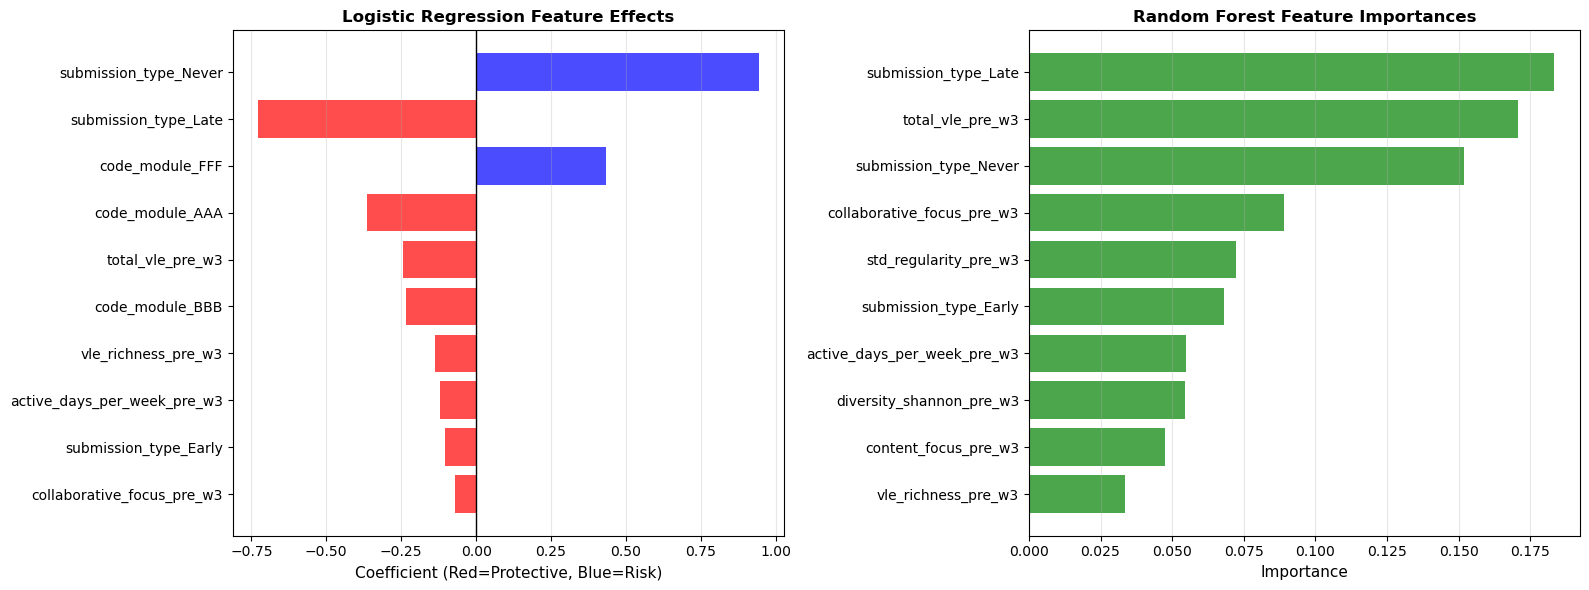

In [27]:
# Feature Importance Analysis
from sklearn.metrics import ConfusionMatrixDisplay

# Get feature names after preprocessing
cat_features = list(final_lr_model.named_steps['preprocess'].named_transformers_['cat_encode'].get_feature_names_out(cat_cols))
scale_features = scale_cols
all_features = scale_features + cat_features

# Logistic Regression coefficients
lr_coefs = final_lr_model.named_steps['classify'].coef_[0]
lr_importance = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': lr_coefs,
    'Abs_Coefficient': np.abs(lr_coefs)
}).sort_values('Abs_Coefficient', ascending=False)

# Random Forest feature importances
rf_featnames = cat_features + scale_features
rf_importance_vals = final_rf_model.named_steps['classify'].feature_importances_
rf_importance = pd.DataFrame({
    'Feature': rf_featnames,
    'Importance': rf_importance_vals
}).sort_values('Importance', ascending=False)

# Display top features
print("=" * 80)
print("LOGISTIC REGRESSION - Top 10 Features")
print("=" * 80)
print(lr_importance.head(10).to_string(index=False))

print("\n" + "=" * 80)
print("RANDOM FOREST - Top 10 Features")
print("=" * 80)
print(rf_importance.head(10).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LR coefficients
top_lr = lr_importance.head(10)
axes[0].barh(range(len(top_lr)), top_lr['Coefficient'], 
             color=['red' if c < 0 else 'blue' for c in top_lr['Coefficient']], alpha=0.7)
axes[0].set_yticks(range(len(top_lr)))
axes[0].set_yticklabels(top_lr['Feature'])
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Coefficient (Red=Protective, Blue=Risk)', fontsize=11)
axes[0].set_title('Logistic Regression Feature Effects', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis='x')

# RF importances
top_rf = rf_importance.head(10)
axes[1].barh(range(len(top_rf)), top_rf['Importance'], color='green', alpha=0.7)
axes[1].set_yticks(range(len(top_rf)))
axes[1].set_yticklabels(top_rf['Feature'])
axes[1].set_xlabel('Importance', fontsize=11)
axes[1].set_title('Random Forest Feature Importances', fontweight='bold', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Run model on test holdout data

TEST SET PERFORMANCE - LOGISTIC REGRESSION vs RANDOM FOREST

Default Threshold (0.5):
              Model  ROC-AUC  Recall  Precision     F1
Logistic Regression   0.7199  0.6388     0.5949 0.6161
      Random Forest   0.7233  0.6072     0.6056 0.6064

CROSS-VALIDATION vs TEST SET COMPARISON
   Metric  LR CV  LR Test  LR Diff  RF CV  RF Test  RF Diff
   Recall 0.6277   0.6388   0.0111 0.6047   0.6072   0.0025
Precision 0.5799   0.5949   0.0150 0.5968   0.6056   0.0088
       F1 0.6029   0.6161   0.0132 0.5993   0.6064   0.0071

THRESHOLD ANALYSIS - TEST SET

Threshold = 0.4:
Model  Threshold  Recall  Precision     F1  FN  FP
   LR     0.4000  0.8427     0.5031 0.6301 179 947
   RF     0.4000  0.8146     0.5223 0.6365 211 848

Threshold = 0.45:
Model  Threshold  Recall  Precision     F1  FN  FP
   LR     0.4500  0.7302     0.5414 0.6218 307 704
   RF     0.4500  0.7144     0.5588 0.6271 325 642

Threshold = 0.5:
Model  Threshold  Recall  Precision     F1  FN  FP
   LR     0.5000  0.6388 

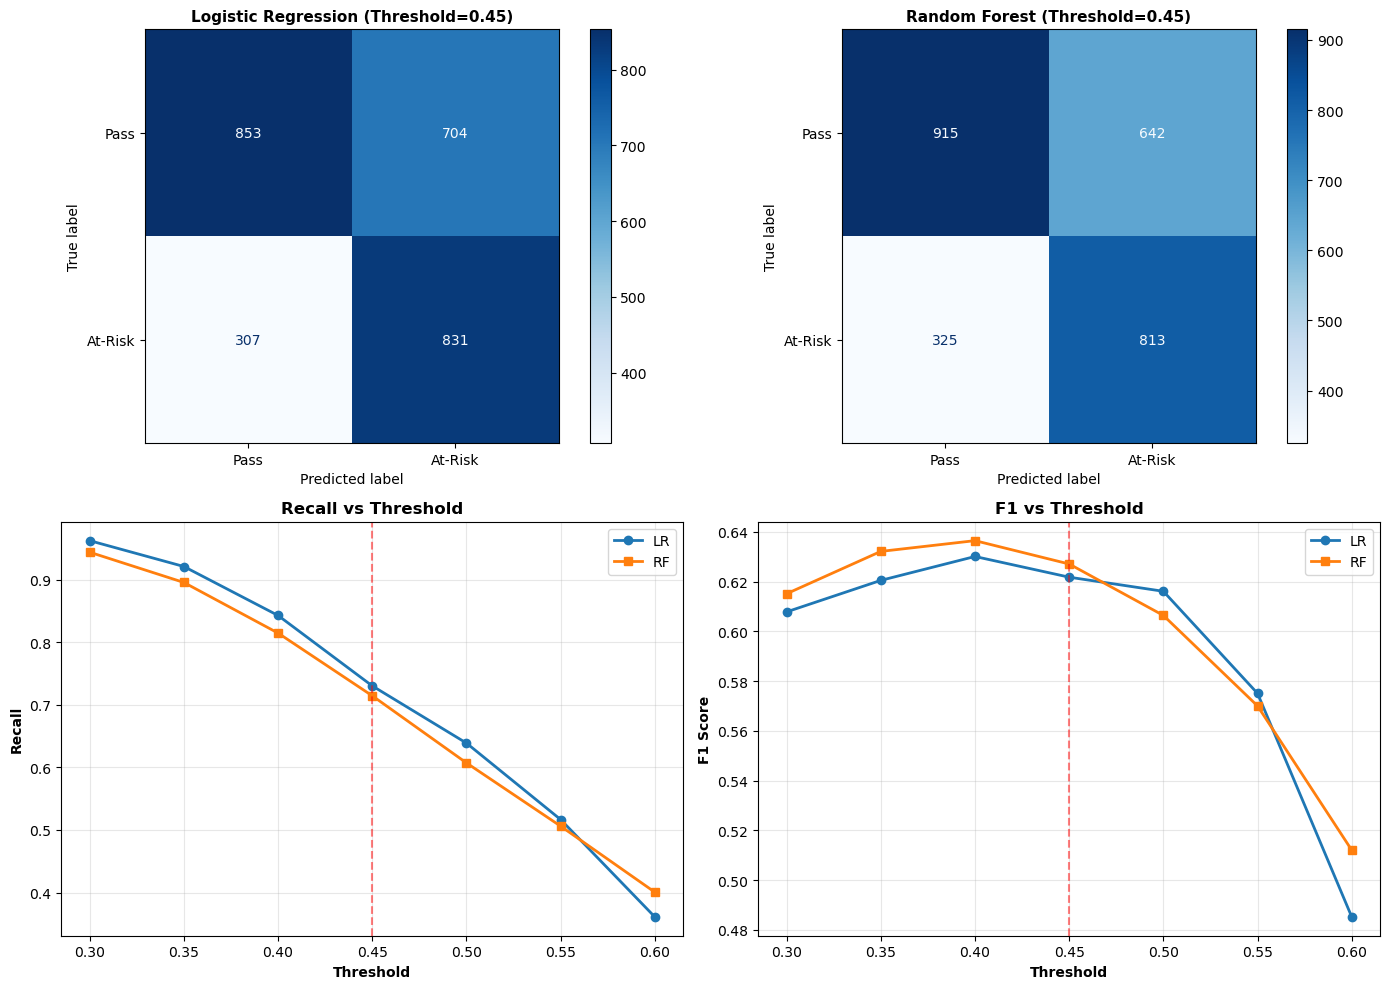


KEY FINDINGS
✓ Test performance is consistent with CV (no significant overfitting)


In [30]:
# Test Set Evaluation: Logistic Regression vs Random Forest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Check if y_test needs conversion (if it's already numeric, skip this)
if y_test.dtype == 'object':
    y_test_numeric = y_test.apply(lambda x: int(x[0]))
else:
    y_test_numeric = y_test

# Get predictions and probabilities
y_pred_lr = final_lr_model.predict(X_test)
y_proba_lr = final_lr_model.predict_proba(X_test)[:, 1]

y_pred_rf = final_rf_model.predict(X_test)
y_proba_rf = final_rf_model.predict_proba(X_test)[:, 1]

print("=" * 90)
print("TEST SET PERFORMANCE - LOGISTIC REGRESSION vs RANDOM FOREST")
print("=" * 90)

# Calculate metrics at default threshold (0.5)
test_results = []
for model_name, y_pred, y_proba in [('Logistic Regression', y_pred_lr, y_proba_lr),
                                     ('Random Forest', y_pred_rf, y_proba_rf)]:
    test_results.append({
        'Model': model_name,
        'ROC-AUC': roc_auc_score(y_test_numeric, y_proba),
        'Recall': recall_score(y_test_numeric, y_pred),
        'Precision': precision_score(y_test_numeric, y_pred),
        'F1': f1_score(y_test_numeric, y_pred)
    })

test_df = pd.DataFrame(test_results)
print("\nDefault Threshold (0.5):")
print(test_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Compare to cross-validation performance
print("\n" + "=" * 90)
print("CROSS-VALIDATION vs TEST SET COMPARISON")
print("=" * 90)
cv_lr = {'Recall': 0.6277, 'Precision': 0.5799, 'F1': 0.6029}
cv_rf = {'Recall': 0.6047, 'Precision': 0.5968, 'F1': 0.5993}

comparison = pd.DataFrame({
    'Metric': ['Recall', 'Precision', 'F1'],
    'LR CV': [cv_lr['Recall'], cv_lr['Precision'], cv_lr['F1']],
    'LR Test': [test_results[0]['Recall'], test_results[0]['Precision'], test_results[0]['F1']],
    'LR Diff': [test_results[0]['Recall'] - cv_lr['Recall'], 
                test_results[0]['Precision'] - cv_lr['Precision'],
                test_results[0]['F1'] - cv_lr['F1']],
    'RF CV': [cv_rf['Recall'], cv_rf['Precision'], cv_rf['F1']],
    'RF Test': [test_results[1]['Recall'], test_results[1]['Precision'], test_results[1]['F1']],
    'RF Diff': [test_results[1]['Recall'] - cv_rf['Recall'],
                test_results[1]['Precision'] - cv_rf['Precision'],
                test_results[1]['F1'] - cv_rf['F1']]
})
print(comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Threshold Analysis on Test Set
print("\n" + "=" * 90)
print("THRESHOLD ANALYSIS - TEST SET")
print("=" * 90)

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
threshold_results = []

for threshold in thresholds:
    for model_name, y_proba in [('LR', y_proba_lr), ('RF', y_proba_rf)]:
        y_pred_thresh = (y_proba >= threshold).astype(int)
        cm = confusion_matrix(y_test_numeric, y_pred_thresh)
        tn, fp, fn, tp = cm.ravel()
        
        threshold_results.append({
            'Model': model_name,
            'Threshold': threshold,
            'Recall': recall_score(y_test_numeric, y_pred_thresh),
            'Precision': precision_score(y_test_numeric, y_pred_thresh),
            'F1': f1_score(y_test_numeric, y_pred_thresh),
            'FN': fn,
            'FP': fp
        })

thresh_df = pd.DataFrame(threshold_results)

# Display key thresholds
for thresh in [0.4, 0.45, 0.5]:
    print(f"\nThreshold = {thresh}:")
    print(thresh_df[thresh_df['Threshold'] == thresh].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion Matrices at threshold 0.45
for idx, (model_name, y_proba) in enumerate([('Logistic Regression', y_proba_lr), 
                                               ('Random Forest', y_proba_rf)]):
    y_pred_45 = (y_proba >= 0.45).astype(int)
    cm = confusion_matrix(y_test_numeric, y_pred_45)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'At-Risk'])
    disp.plot(cmap='Blues', ax=axes[0, idx], values_format='d')
    axes[0, idx].set_title(f'{model_name} (Threshold=0.45)', fontweight='bold', fontsize=11)

# Threshold curves
lr_data = thresh_df[thresh_df['Model'] == 'LR']
rf_data = thresh_df[thresh_df['Model'] == 'RF']

axes[1, 0].plot(lr_data['Threshold'], lr_data['Recall'], 'o-', label='LR', linewidth=2)
axes[1, 0].plot(rf_data['Threshold'], rf_data['Recall'], 's-', label='RF', linewidth=2)
axes[1, 0].axvline(x=0.45, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Threshold', fontweight='bold')
axes[1, 0].set_ylabel('Recall', fontweight='bold')
axes[1, 0].set_title('Recall vs Threshold', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(lr_data['Threshold'], lr_data['F1'], 'o-', label='LR', linewidth=2)
axes[1, 1].plot(rf_data['Threshold'], rf_data['F1'], 's-', label='RF', linewidth=2)
axes[1, 1].axvline(x=0.45, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Threshold', fontweight='bold')
axes[1, 1].set_ylabel('F1 Score', fontweight='bold')
axes[1, 1].set_title('F1 vs Threshold', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 90)
print("KEY FINDINGS")
print("=" * 90)
print(f"✓ Test performance is consistent with CV (no significant overfitting)")